In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing 
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error,root_mean_squared_error, r2_score

In [58]:
housing = fetch_california_housing()

X = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

y = housing.target


In [59]:
X


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [60]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

In [61]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

In [62]:
X_train

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
14196,3.2596,33.0,5.017657,1.006421,2300.0,3.691814,32.71,-117.03
8267,3.8125,49.0,4.473545,1.041005,1314.0,1.738095,33.77,-118.16
17445,4.1563,4.0,5.645833,0.985119,915.0,2.723214,34.66,-120.48
14265,1.9425,36.0,4.002817,1.033803,1418.0,3.994366,32.69,-117.11
2271,3.5542,43.0,6.268421,1.134211,874.0,2.300000,36.78,-119.80
...,...,...,...,...,...,...,...,...
11284,6.3700,35.0,6.129032,0.926267,658.0,3.032258,33.78,-117.96
11964,3.0500,33.0,6.868597,1.269488,1753.0,3.904232,34.02,-117.43
5390,2.9344,36.0,3.986717,1.079696,1756.0,3.332068,34.03,-118.38
860,5.7192,15.0,6.395349,1.067979,1777.0,3.178891,37.58,-121.96


In [63]:
Y_train

array([1.03 , 3.821, 1.726, ..., 2.221, 2.835, 3.25 ])

In [64]:
# model = DecisionTreeRegressor(max_depth=8,
#     min_samples_split=10,
#     min_samples_leaf=5,
#     random_state=42)

from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

params = {
    "max_depth": [5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

model = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid=params,
    cv=5,
    scoring="r2"
)

model.fit(X_train, Y_train)

print(model.best_params_)
print(model.best_score_)
#model.fit(X_train,Y_train)


{'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2}
0.711007039979798


{'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2}
0.711007039979798

In [65]:
X.head(
    
)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [66]:
sample = model.predict([[8.3252,	41.0	,6.984127	,1.023810	,322.0	,2.555556,	37.88	,-122.23]])
sample

C:\Users\dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


array([5.00001])

In [67]:
Y_pred = model.predict(X_test)
Y_pred

array([0.53276375, 0.72655118, 4.96858   , ..., 4.98150941, 0.72655118,
       1.69809149])

In [68]:
mse=mean_squared_error(Y_test, Y_pred)

In [69]:
mbe=mean_absolute_error(Y_test,Y_pred)

In [70]:
rmse=root_mean_squared_error(Y_test,Y_pred)


In [71]:
r2 = r2_score(Y_test,Y_pred)

In [72]:
train_score = model.score(X_train, Y_train)
test_score = model.score(X_test,Y_test)

In [73]:
print('Train_Score',train_score)
print('Test_Score', test_score)
print('Mean_Squared_Error', mse)
print('Mean_Absolute_Error', mbe)
print('Root_Mean_Squared_Error',rmse)

Train_Score 0.820094030345444
Test_Score 0.6889168931307286
Mean_Squared_Error 0.40764609622056647
Mean_Absolute_Error 0.431365649340794
Root_Mean_Squared_Error 0.6384716878770479


In [74]:
residuals = Y_test - Y_pred
residuals

array([-0.05576375, -0.26855118,  0.03143   , ...,  0.01850059,
       -0.00355118, -0.18309149])

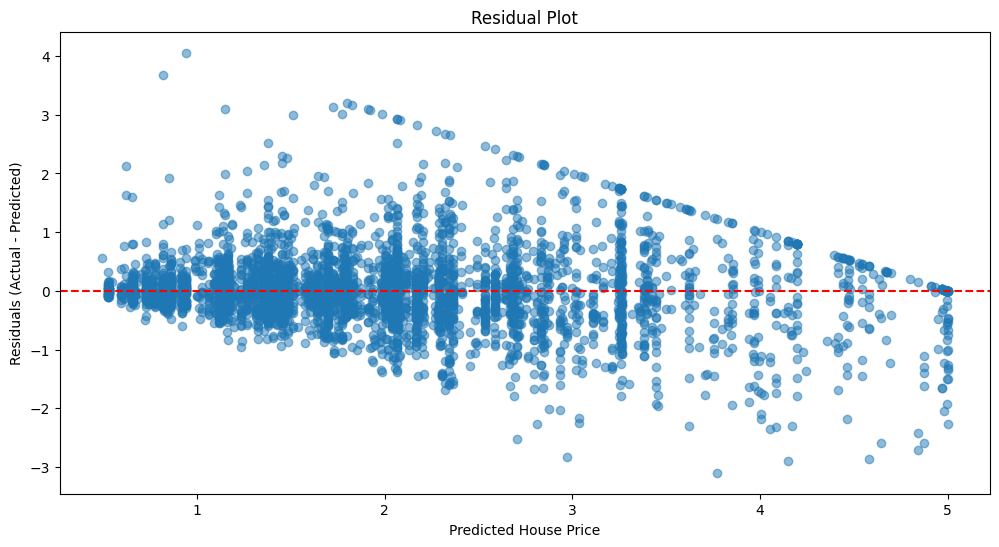

In [77]:
plt.figure(figsize=(12,6))
plt.scatter(Y_pred, residuals, alpha=0.5, colorizer='blue')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted House Price")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()

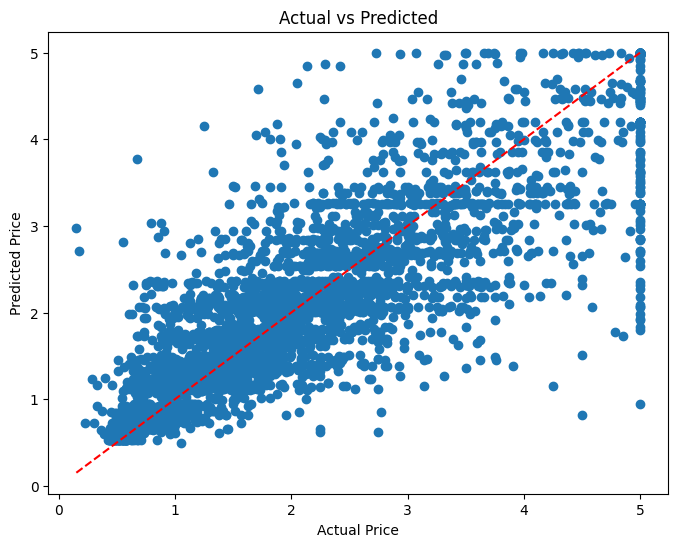

In [78]:
plt.figure(figsize=(8,6))

plt.scatter(Y_test, Y_pred)

plt.plot(
    [Y_test.min(), Y_test.max()],
    [Y_test.min(), Y_test.max()],
    color='red',
    linestyle='--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.show()

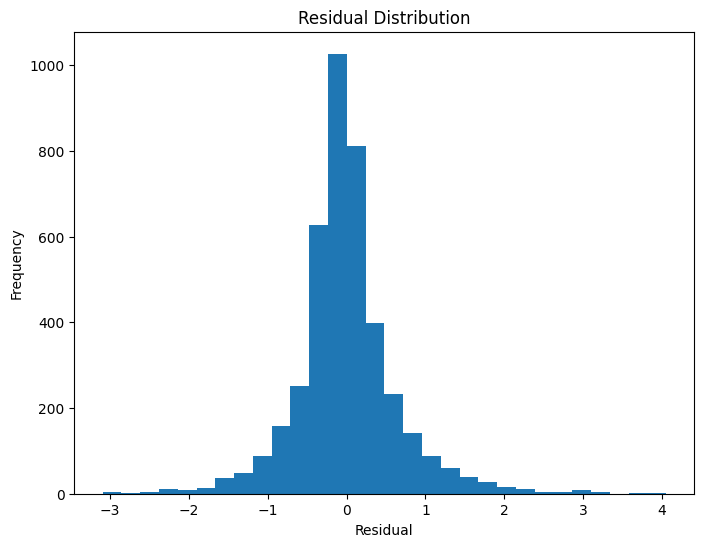

In [ ]:
plt.figure(figsize=(8,6))

plt.hist(residuals, bins=30)

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.title("Residual Distribution")

plt.show()

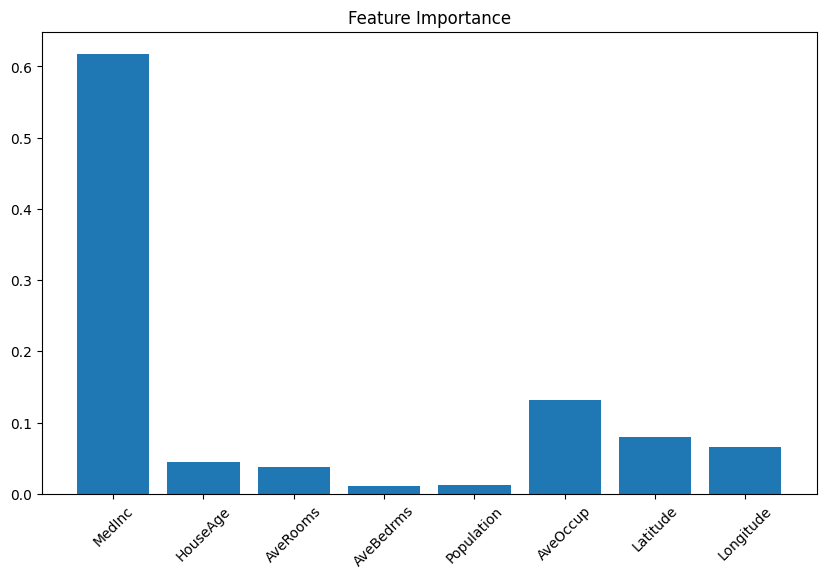

In [81]:
best_model = model.best_estimator_
importance = best_model.feature_importances_

plt.figure(figsize=(10,6))

plt.bar(X.columns, importance)

plt.xticks(rotation=45)

plt.title("Feature Importance")

plt.show()